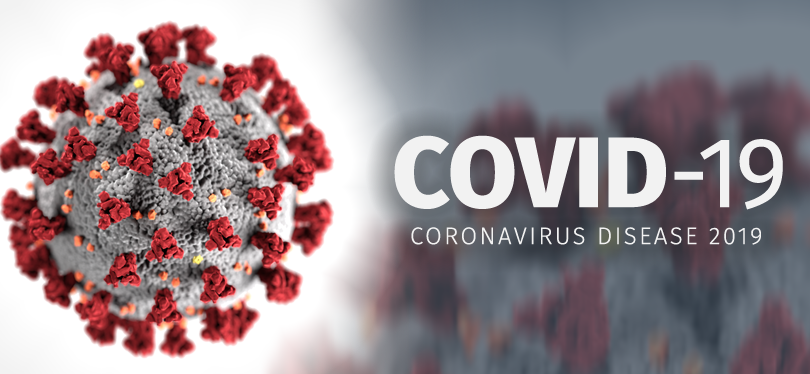

#Covid 19 Project

#Introduction:
The COVID-19 Pandemic ContextThe COVID-19 pandemic, caused by the SARS-CoV-2 virus, originated in Wuhan, China, with the first documented cases appearing in December 2019. Due to its high transmissibility and severe health impacts, the World Health Organization (WHO) declared the outbreak a Public Health Emergency of International Concern on January 30, 2020, and officially characterized it as a pandemic on March 11, 2020.

The virus rapidly spread globally, leading to significant disruptions in daily life, economic systems, and healthcare infrastructure. Over the subsequent years, multiple variants of concern—including Alpha, Delta, and Omicron—emerged, prompting further waves of infection and evolving public health strategies. According to the WHO Coronavirus Dashboard, the pandemic resulted in hundreds of millions of confirmed cases and millions of deaths worldwide, though the true death toll is estimated to be higher. The global emergency phase officially ended in May 2023, though the virus continues to circulate.

This project leverages data analytics, modeling, and visualization to analyze the patterns, spread, and impacts of this unprecedented global health event.

#Problem Statement:

Given data about COVID-19 patients, write code to visualize the impact and
analyze the trend of rate of infection and recovery as well as make predictions
about the number of cases expected a week in future based on the current
trends.

#Dataset:
CSV and Excel files containing data about the number of COVID-19 confirmed
deaths and recovered patients both around the world and in India. Download Link

#Important Note:

● We will Use pandas to accumulate data from multiple data files.

● We will Use plotly (visualization library) to create interactive visualizations.

● We will Use Facebook prophet library to make time series models.

● We will Visualize the prediction by combining these technologies.

#_________________________________________________________________________________________________________

#Install and Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')  # to help remove warning statments along with output

# Reading dataset

In [4]:
df = pd.read_csv('/content/covid_19_clean_complete.csv')
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


# Exploratory Data Analysis

In [5]:
# Shape of dataset
df.shape

(49068, 10)

In [6]:
# Checking info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [7]:
# Renaming correct columns

df.rename(columns={'Province/State':'State',             # We will rename it in the form of Dictionary.
           'Country/Region':'Country'}, inplace = True)  # Inplace=True will make the change permanent.
df.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [8]:
# Getting value count of Date field

df.Date.value_counts()

# We will see that from start till the end, every single date is repeating 261 times.
# I.e. for every Country/Region/State, on that particular date there are 261 records in the dataset.

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


#we can see that max date will be 2020-07-27

In [9]:
# check max date

df['Date'].max()

'2020-07-27'

In [10]:
# poulating rows with max date in top

top = df[df['Date'] == '2020-07-27']
top

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [11]:
# The total country count is less as compared to the record.
# It means that on a given date, the country record is repeating. (Maybe due to high cases, cases are recorded in morning and evening)

df["Country"].nunique()

187

In [12]:
# Grouping all rows absed on country

top.groupby(by='Country')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

# We are grouping the data based on the country and finding the total sum.
# With reset index we are putting the entire data in a DataFrame with an index value.

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


In [13]:
# Populating all confirmed case in confirmed dataset

confirmed = df.groupby(by='Date')['Confirmed'].sum().reset_index()
confirmed

# We are grouping the data based on the Date and finding the total sum of confirmed cases.
# With reset index we are putting the entire data in a DataFrame with an index value.

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


## We have 188 unique Dates, each date is repeating 261 times
## We have 187 Unique countires where data for these 187 cuntries are recorded for each date

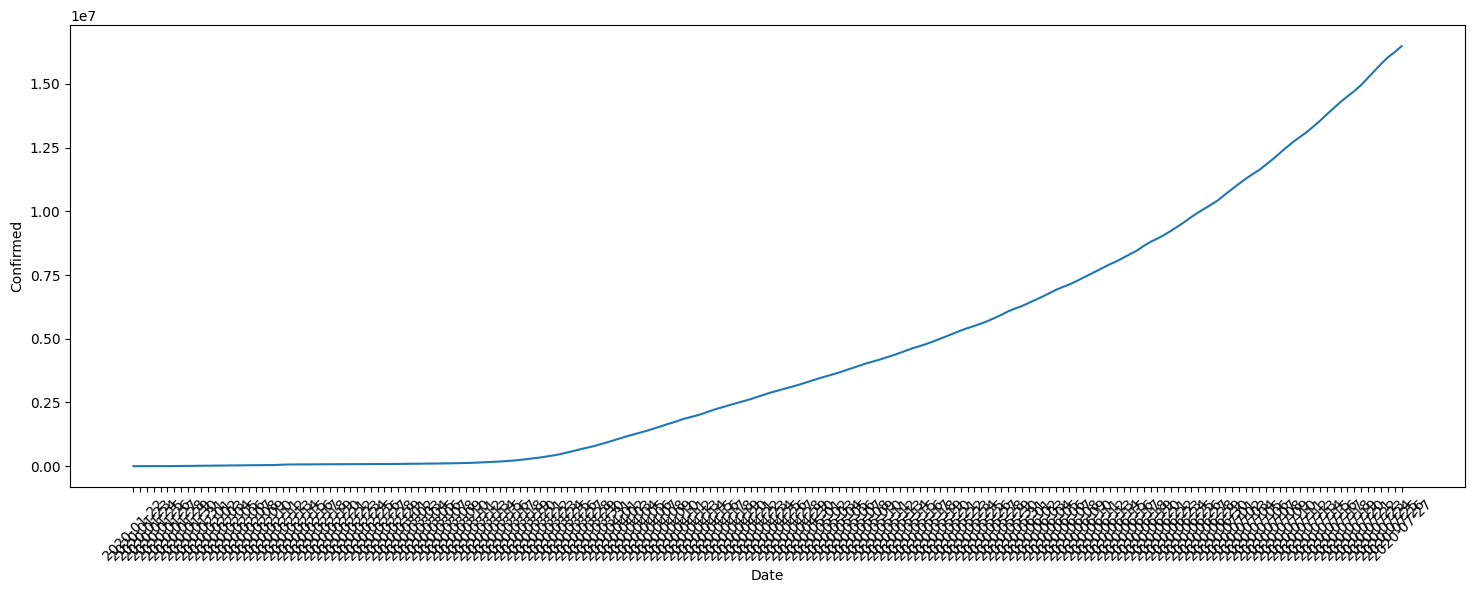

In [14]:
# Visualizing confirmed case
plt.figure(figsize = (18,6))
sns.lineplot(data=confirmed, x='Date', y='Confirmed')
plt.xticks(rotation=45)
plt.show()

#Top 10 countries with the most recovered cases

In [15]:
top_10_recovered = df.groupby(by='Country')['Recovered'].sum().sort_values(ascending = False).head(10).reset_index()
top_10_recovered

# We will group by all the data bsed on the countries and then take the sum of all the recovered cases.
# We will sort the data in Descending order to find Top 10 countries.
# With reset index we are putting the entire data in a DataFrame with an index value.

,Country,Recovered
0,US,56353416
1,Brazil,54492873
2,Russia,25120448
3,India,23783720
4,Germany,17107839
5,Italy,15673910
6,Iran,15200895
7,Spain,15093583
8,Turkey,13345389
9,Chile,13292593


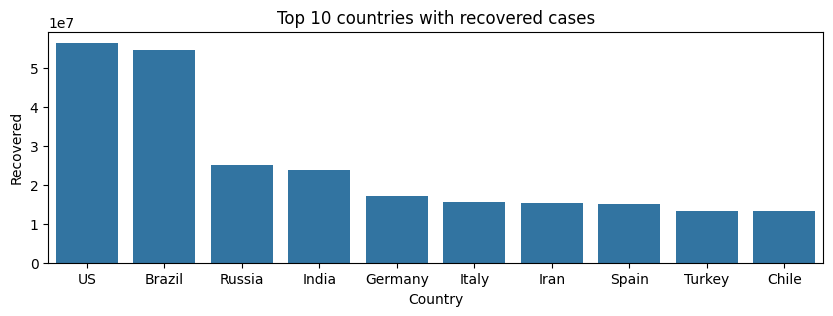

In [16]:
# Visualizing recovered case

plt.figure(figsize = (10,3))
sns.barplot(data = top_10_recovered, x = 'Country', y='Recovered')
plt.title('Top 10 countries with recovered cases')
plt.show()

#Top 10 countries with deaths

In [17]:
top_10_deaths = df.groupby(by='Country')['Deaths'].sum().sort_values(ascending = False).head(10).reset_index()
top_10_deaths

# We will group by all the data bsed on the countries and then take the sum of all the death cases.
# We will sort the data in Descending order to find Top 10 countries.
# With reset index we are putting the entire data in a DataFrame with an index value.

,Country,Deaths
0,US,11011411
1,United Kingdom,3997775
2,Brazil,3938034
3,Italy,3707717
4,France,3048524
5,Spain,3033030
6,Mexico,1728277
7,India,1111831
8,Iran,1024136
9,Belgium,963679


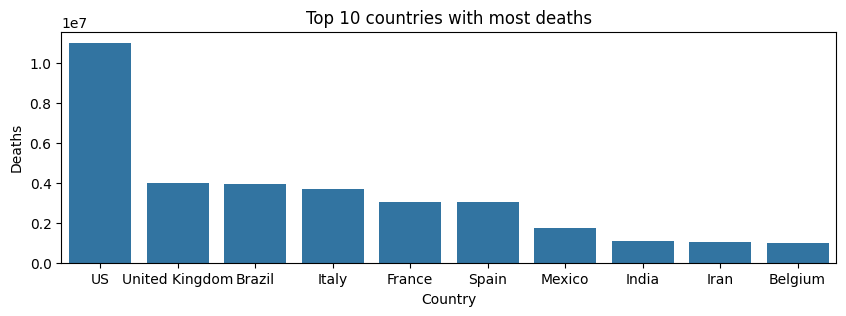

In [18]:
# Visualizing deaths case

plt.figure(figsize = (10,3))
sns.barplot(data = top_10_deaths, x = 'Country', y = 'Deaths')
plt.title('Top 10 countries with most deaths')
plt.show()

#Top 10 countries with most active cases

In [19]:
top_10_active = df.groupby(by='Country')['Active'].sum().sort_values(ascending = False).head(10).reset_index()
top_10_active

# We will group by all the data bsed on the countries and then take the sum of all the active cases.
# We will sort the data in Descending order to find Top 10 countries.
# With reset index we are putting the entire data in a DataFrame with an index value.

,Country,Active
0,US,156981121
1,Brazil,31094060
2,United Kingdom,22624595
3,Russia,19668578
4,India,15987913
5,France,10980287
6,Spain,9277432
7,Canada,8656985
8,Peru,7748957
9,Italy,7363518


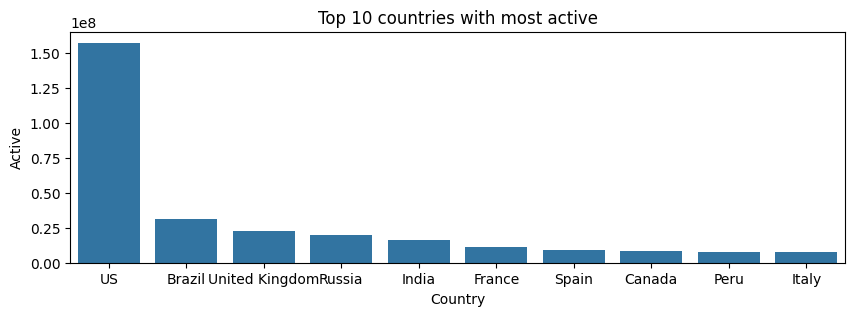

In [20]:
# Visualizing active case

plt.figure(figsize = (10,3))
sns.barplot(data = top_10_active, x = 'Country', y = 'Active')
plt.title('Top 10 countries with most active')
plt.show()

#Country Based Analysis

1st US

2nd China

3rd India

In [21]:
# Creating US dataset which have country as US

US = df[df['Country'] == 'US']
US


,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [22]:
US = US.groupby(by='Date')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
US

# As per the data based on US, We will group the data based on the date and check the Sum of all type of cases.
# With reset index we are putting the entire data in a DataFrame with an index value.

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,4038816,144430,1233269,2661117
184,2020-07-24,4112531,145560,1261624,2705347
185,2020-07-25,4178970,146465,1279414,2753091
186,2020-07-26,4233923,146935,1297863,2789125


In [23]:
# Creating China dataset which have country as China

China = df[df['Country'] == 'China']
China.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific


In [24]:
China = China.groupby(by='Date')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
China

# As per the data based on China, We will group the data based on the date and check the Sum of all type of cases.
# With reset index we are putting the entire data in a DataFrame with an index value.

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,548,17,28,503
1,2020-01-23,643,18,30,595
2,2020-01-24,920,26,36,858
3,2020-01-25,1406,42,39,1325
4,2020-01-26,2075,56,49,1970
...,...,...,...,...,...
183,2020-07-23,86045,4649,78701,2695
184,2020-07-24,86202,4650,78745,2807
185,2020-07-25,86381,4652,78813,2916
186,2020-07-26,86570,4652,78862,3056


In [25]:
# Creating India dataset which have country as India

India = df[df['Country'] == 'India']
India

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


In [26]:
India = India.groupby(by='Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
India

# As per the data based on India, We will group the data based on the date and check the Sum of all type of cases.
# With reset index we are putting the entire data in a DataFrame with an index value.

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,1288108,30601,817209,440298
184,2020-07-24,1337024,31358,849432,456234
185,2020-07-25,1385635,32060,885573,468002
186,2020-07-26,1435616,32771,917568,485277


#Compare these countries on the basis of Recovered cases

Text(0, 0.5, 'No. of Recovered')

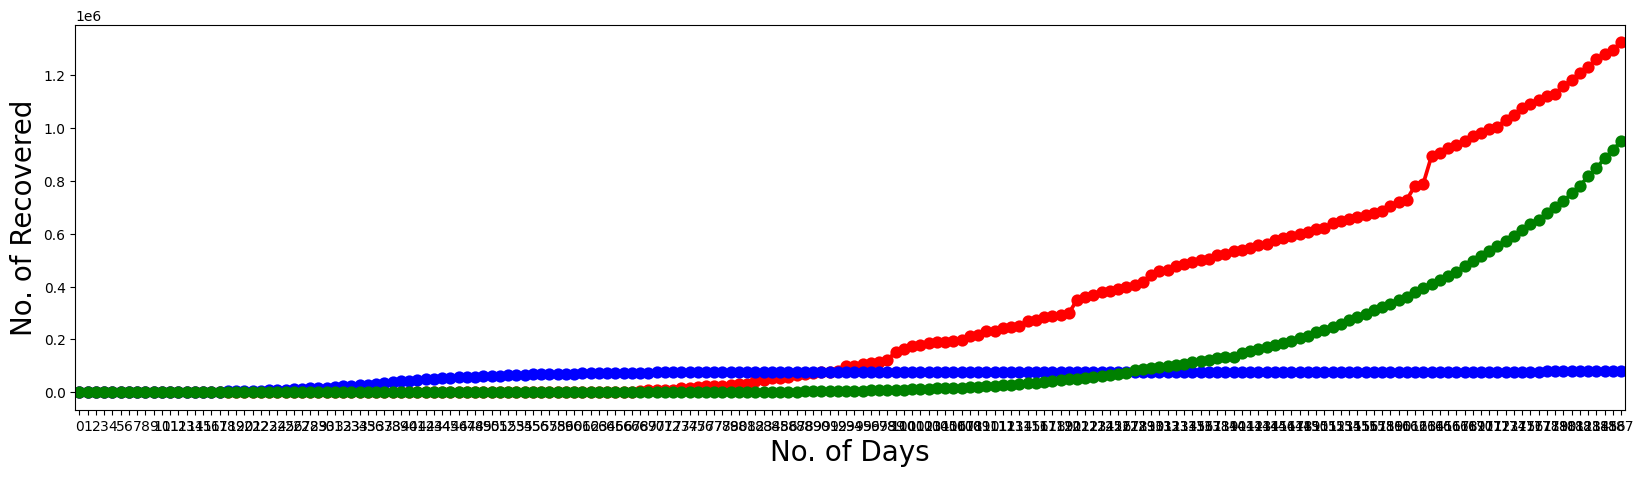

In [27]:
# Visualizing using point plot
plt.figure(figsize=(20,5))

sns.pointplot(x=US.index, y = US.Recovered, color = 'Red')
sns.pointplot(x=China.index, y=China.Recovered, color = 'Blue')
sns.pointplot(x=India.index, y=India.Recovered, color = 'Green')

plt.xlabel('No. of Days', fontsize = 20)
plt.ylabel('No. of Recovered', fontsize = 20)

#Compare these countries on the basis of Deaths cases

Text(0, 0.5, 'No. of Recovered')

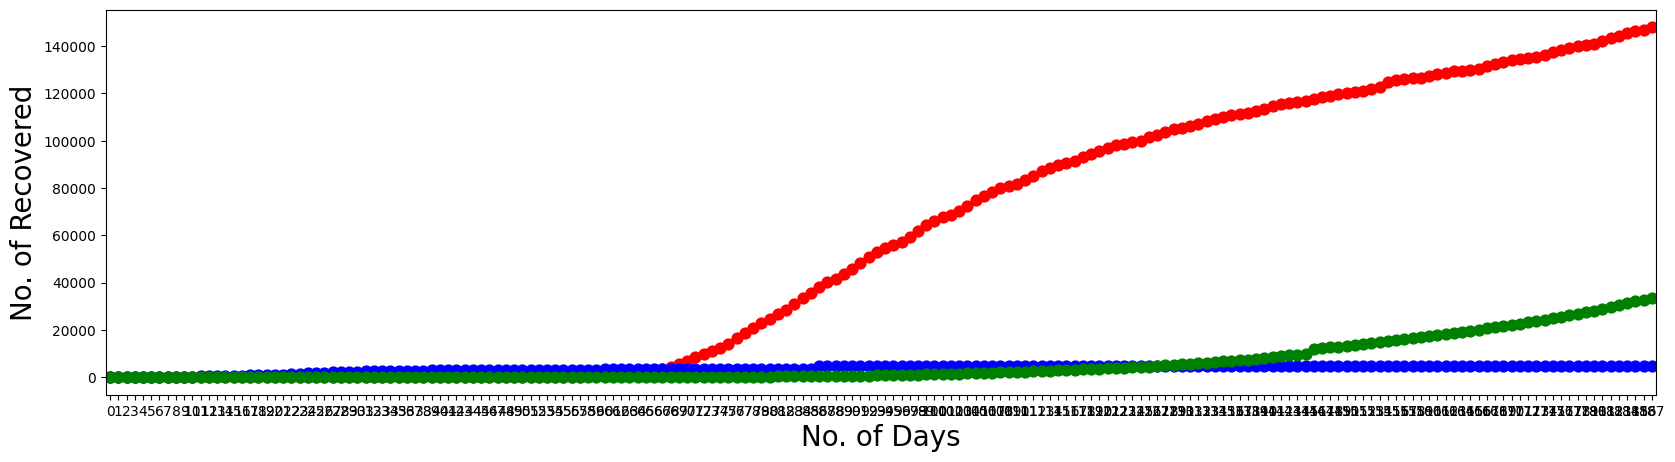

In [28]:
# Visualizing using point plot
plt.figure(figsize=(20,5))

sns.pointplot(x=US.index, y = US.Deaths, color = 'Red')
sns.pointplot(x=China.index, y=China.Deaths, color = 'Blue')
sns.pointplot(x=India.index, y=India.Deaths, color = 'Green')

plt.xlabel('No. of Days', fontsize = 20)
plt.ylabel('No. of Recovered', fontsize = 20)

#Compare these countries on the basis of Active cases

Text(0, 0.5, 'No. of Recovered')

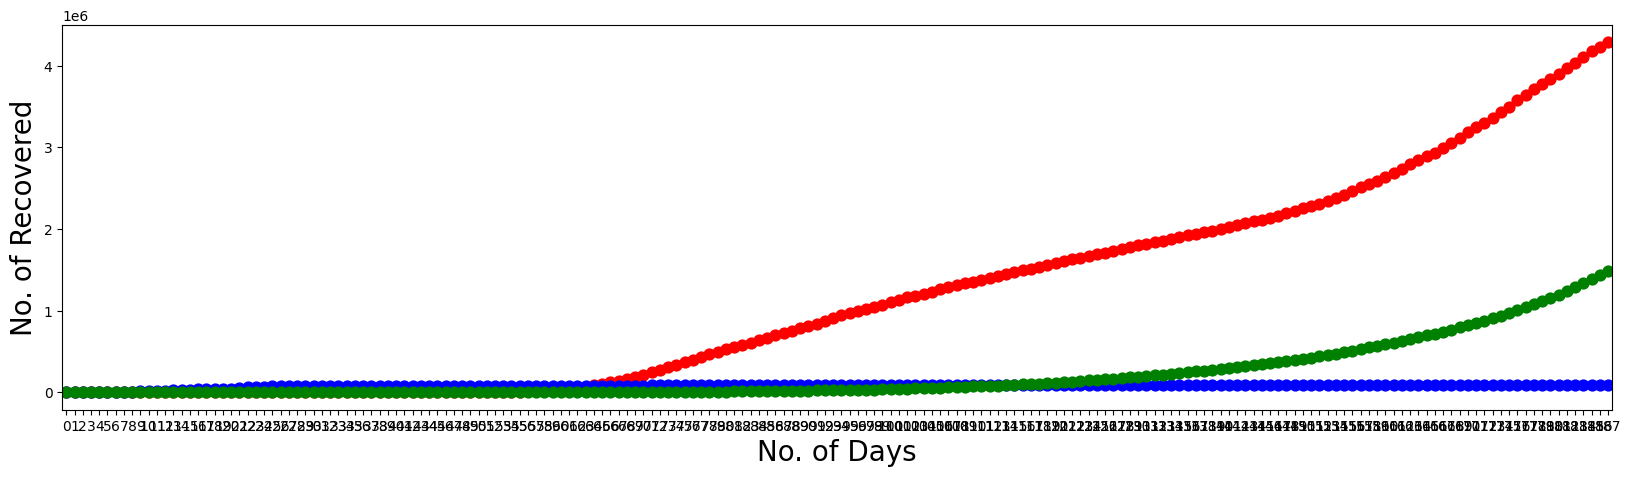

In [29]:
# Visualizing using point plot
plt.figure(figsize=(20,5))

sns.pointplot(x=US.index, y = US.Confirmed, color = 'Red')
sns.pointplot(x=China.index, y=China.Confirmed, color = 'Blue')
sns.pointplot(x=India.index, y=India.Confirmed, color = 'Green')

plt.xlabel('No. of Days', fontsize = 20)
plt.ylabel('No. of Recovered', fontsize = 20)

#Model Building

We will be using a FB Prophet model for Time Series Analysis developed by Facebook that's designed to be used easily and which is effective for a wide range of Time Series Data.

We will a Time Series model because we need to forecast all the Covid 19 Cases.

Based on a pattern of the cases till 27th July 2020, we will forecast the cases.

In [30]:
!pip install plotly

Prophet is a time series forecasting tool developed by Facebook that’s designed to be easy to use and effective for a wide range
of time series data. It’s particularly useful for data that has strong seasonal effects (like daily or weekly patterns) and includes
important dates or events that can impact the forecast.

In [31]:
# Intalling prophet
!pip install prophet

In [32]:
!pip install --upgrade prophet pystan cmdstanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.0 MB/s eta 0:00:00


In [33]:
# Reading dataset

df1 = pd.read_csv('/content/covid_19_clean_complete.csv', parse_dates=['Date'])
df1.head()

# WE are making the date column as Date Time Format.
# We can also use pd.to_datetime()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [34]:
# Checking info of dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [35]:
# creating new dataset of Confirmed cases

confirmed = df1.groupby(by='Date')['Confirmed'].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [36]:
# creating new dataset of Deaths cases

deaths = df1.groupby(by='Date').sum()['Deaths'].reset_index()
deaths

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [37]:
# creating new dataset of Recovered cases

recovered = df1.groupby(by='Date').sum()['Recovered'].reset_index()
recovered.head()

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52


In [38]:
# creating new dataset of Active cases

active = df1.groupby(by='Date').sum()['Active'].reset_index()
active.head()

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010


#Forecasting for confirmed cases

In [39]:
# renaming confirmed columns to ds and y

confirmed.columns = ['ds','y']
confirmed.head()

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [40]:
# importing prophet library

from prophet import Prophet
m = Prophet()

# We will create a simple variable and store the model inside that variable.

In [41]:
m.fit(confirmed)

# Here we will Fit the model with the Confirmed data.

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [42]:
# Making prediction for next 14 dates

future = m.make_future_dataframe(periods=14)

# We will use an Inbuilt function from the model which is make_future_dataframe.
# It is having a parameter period = 14, which will forecast for next 14 days.
# Here we are making a new dataframe.

In [43]:
future.tail(15)

# To check the last 14 dates created.

,ds
187,2020-07-27
188,2020-07-28
189,2020-07-29
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02
194,2020-08-03
195,2020-08-04
196,2020-08-05


In [44]:
forecast = m.predict(future)
forecast.tail(15)

# Here we are making where yhat is the predicted value.
# Here the lower and upper is the limit between which the predicted value will remain.

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
187,2020-07-27,1.613306e+07,1.602421e+07,1.623979e+07,1.613306e+07,1.613306e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.613096e+07
188,2020-07-28,1.633705e+07,1.620789e+07,1.641488e+07,1.633705e+07,1.633705e+07,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,0.0,0.0,0.0,1.632021e+07
189,2020-07-29,1.654104e+07,1.641985e+07,1.663119e+07,1.654077e+07,1.654382e+07,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,1.652998e+07
190,2020-07-30,1.674503e+07,1.663655e+07,1.684642e+07,1.674102e+07,1.675414e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685225e+07,1.707000e+07,1.694036e+07,1.696589e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705899e+07,1.728323e+07,1.713696e+07,1.717908e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725151e+07,1.747493e+07,1.733236e+07,1.739121e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07
194,2020-08-03,1.756100e+07,1.745265e+07,1.768936e+07,1.752665e+07,1.760565e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.755889e+07
195,2020-08-04,1.776499e+07,1.763414e+07,1.787081e+07,1.771887e+07,1.782237e+07,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,0.0,0.0,0.0,1.774814e+07
196,2020-08-05,1.796898e+07,1.782609e+07,1.810265e+07,1.790841e+07,1.804123e+07,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,1.795791e+07


In [45]:
confirmed

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [46]:
forecast_next_14_days = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(14)
forecast_next_14_days

,ds,yhat,yhat_lower,yhat_upper
188,2020-07-28,1.632021e+07,1.620789e+07,1.641488e+07
189,2020-07-29,1.652998e+07,1.641985e+07,1.663119e+07
190,2020-07-30,1.674392e+07,1.663655e+07,1.684642e+07
191,2020-07-31,1.695911e+07,1.685225e+07,1.707000e+07
192,2020-08-01,1.716677e+07,1.705899e+07,1.728323e+07
193,2020-08-02,1.736430e+07,1.725151e+07,1.747493e+07
194,2020-08-03,1.755889e+07,1.745265e+07,1.768936e+07
195,2020-08-04,1.774814e+07,1.763414e+07,1.787081e+07
196,2020-08-05,1.795791e+07,1.782609e+07,1.810265e+07
197,2020-08-06,1.817185e+07,1.804298e+07,1.830808e+07


In [47]:
forecast[['ds','yhat','yhat_upper','yhat_lower']]

,ds,yhat,yhat_upper,yhat_lower
0,2020-01-22,-2.067685e+04,8.243511e+04,-1.202282e+05
1,2020-01-23,-8.050953e+03,8.769975e+04,-1.173371e+05
2,2020-01-24,5.827449e+03,1.127891e+05,-8.860155e+04
3,2020-01-25,1.217668e+04,1.204920e+05,-8.694938e+04
4,2020-01-26,8.405020e+03,1.155795e+05,-9.331872e+04
...,...,...,...,...
197,2020-08-06,1.817185e+07,1.830808e+07,1.804298e+07
198,2020-08-07,1.838704e+07,1.853240e+07,1.824353e+07
199,2020-08-08,1.859470e+07,1.875337e+07,1.843942e+07
200,2020-08-09,1.879224e+07,1.895590e+07,1.863393e+07


#Columns in the Output


-ds:The timestamps for which predictions are made (from the input DataFrame or future DataFrame).



-yhat: The predicted value (forecasted output) for the corresponding date in ds.



-yhat_lower and yhat_upper: The lower and upper bounds of the uncertainty interval for the forecast. These values are derived from the model’s uncertainty settings and provide a confidence interval.


-trend: The estimated trend component of the forecast, capturing long-term movement.


-trend_lower and trend_upper: The lower and upper bounds for the uncertainty interval of the trend component.


-seasonal: The aggregated seasonal component of the forecast (sum of all seasonalities like daily, weekly, yearly).


-seasonal_lower and seasonal_upper: The uncertainty intervals for the aggregated seasonal component.


-seasonal_X (e.g., seasonal_weekly, seasonal_yearly, etc.): These columns correspond to specific seasonal components if multiple seasonalities were specified during model setup.


-additive_terms: The sum of all additive components (e.g., trend, seasonal, extra regressors if applicable).


-additive_terms_lower and additive_terms_upper: Uncertainty intervals for the additive terms.


-multiplicative_terms (if applicable): The sum of all multiplicative components, used when the model is set to multiplicative seasonality.



-multiplicative_terms_lower and multiplicative_terms_upper: Uncertainty intervals for the multiplicative terms.


#How to Use the Output


-Forecast Plotting: Use ds and yhat to plot the main forecast, while yhat_lower and yhat_upper are used for confidence intervals.


-Component Analysis: Analyze the contributions of trend, seasonal, and other components (e.g., extra regressors) to the forecast.

In [48]:
forecast[['ds','yhat','yhat_upper','yhat_lower']]

,ds,yhat,yhat_upper,yhat_lower
0,2020-01-22,-2.067685e+04,8.243511e+04,-1.202282e+05
1,2020-01-23,-8.050953e+03,8.769975e+04,-1.173371e+05
2,2020-01-24,5.827449e+03,1.127891e+05,-8.860155e+04
3,2020-01-25,1.217668e+04,1.204920e+05,-8.694938e+04
4,2020-01-26,8.405020e+03,1.155795e+05,-9.331872e+04
...,...,...,...,...
197,2020-08-06,1.817185e+07,1.830808e+07,1.804298e+07
198,2020-08-07,1.838704e+07,1.853240e+07,1.824353e+07
199,2020-08-08,1.859470e+07,1.875337e+07,1.843942e+07
200,2020-08-09,1.879224e+07,1.895590e+07,1.863393e+07


In [49]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.202282e+05,8.243511e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.173371e+05,8.769975e+04,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-8.860155e+04,1.127891e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-8.694938e+04,1.204920e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-9.331872e+04,1.155795e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,2020-08-06,1.817297e+07,1.804298e+07,1.830808e+07,1.809783e+07,1.825976e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.817185e+07
198,2020-08-07,1.837696e+07,1.824353e+07,1.853240e+07,1.828867e+07,1.847716e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.838704e+07
199,2020-08-08,1.858095e+07,1.843942e+07,1.875337e+07,1.847758e+07,1.869627e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.859470e+07
200,2020-08-09,1.878494e+07,1.863393e+07,1.895590e+07,1.866514e+07,1.891396e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.879224e+07


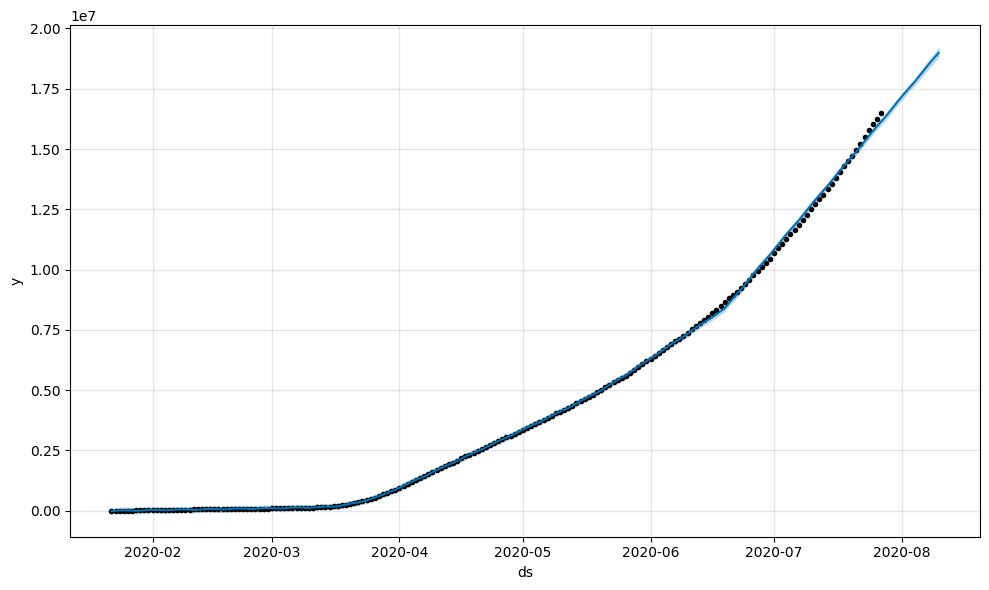

In [50]:
# Visualizing

import matplotlib.pyplot as plt
m.plot(forecast)
plt.show()

# The dotted points are the actual data and the blue line is the forcasted data.

In [51]:
# Importing plotly library

import plotly
import plotly.express as px

In [52]:
world = df1.groupby(by='Country/Region')[['Confirmed','Active','Deaths','Recovered']].sum().reset_index()
world

,Country/Region,Confirmed,Active,Deaths,Recovered
0,Afghanistan,1936390,1089052,49098,798240
1,Albania,196702,72117,5708,118877
2,Algeria,1179755,345886,77972,755897
3,Andorra,94404,19907,5423,69074
4,Angola,22662,15011,1078,6573
...,...,...,...,...,...
182,West Bank and Gaza,233461,170967,1370,61124
183,Western Sahara,901,190,63,648
184,Yemen,67180,25694,17707,23779
185,Zambia,129421,43167,2643,83611


In [53]:
# visualizing using plotly library
figure = px.choropleth(world,locations='Country/Region',
                        locationmode = 'country names',
                        color='Confirmed',
                        hover_name='Country/Region', range_color=[1,20000],
                        color_continuous_scale='Viridis',
                        title='Countries with Active Cases')
figure.show()

# choropleth is a function in Plotly Library which will represent the data in the form of a Worldmap.

#Accuracy Test

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Align the forecast with the original confirmed data
# We need to make sure we are comparing the predicted values (yhat) with the actual values (y)
# for the dates that were part of the original training data.

# Extract actual values from the 'confirmed' DataFrame (training data)
actual_values = confirmed['y']

# Extract predicted values from the 'forecast' DataFrame for the corresponding dates
# The 'forecast' dataframe contains predictions for all dates, including the historical ones.
# We need to select only the predictions that correspond to the dates in 'confirmed'.
predicted_values_on_training = forecast['yhat'].iloc[:len(confirmed)]

# Calculate performance metrics
mae = mean_absolute_error(actual_values, predicted_values_on_training)
mse = mean_squared_error(actual_values, predicted_values_on_training)
rmse = np.sqrt(mse)
r2 = r2_score(actual_values, predicted_values_on_training)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (MAE): 42758.84
Mean Squared Error (MSE): 6799256061.26
Root Mean Squared Error (RMSE): 82457.60
R-squared (R2) Score: 0.9997


#_________________________________________________________________________________________________________________